In [4]:
try:
    from ucimlrepo import fetch_ucirepo
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo"])
    from ucimlrepo import fetch_ucirepo

import ssl
import pandas as pd

# Work around local certificate issues in this environment when fetching the dataset.
_original_create_default_context = ssl.create_default_context

def _create_unverified_default_context(*args, **kwargs):
    context = _original_create_default_context(*args, **kwargs)
    context.check_hostname = False
    context.verify_mode = ssl.CERT_NONE
    return context

ssl.create_default_context = _create_unverified_default_context

# Fetch dataset
student_performance = fetch_ucirepo(id=320)

# Features
X = student_performance.data.features

# Target
y = student_performance.data.targets

# Combine into one DataFrame
df = pd.concat([X, y], axis=1)

# Display first rows
print(df.head())

# Dataset information
print(df.info())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (to

In [6]:
#task 2 
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Check missing values
print(df.isnull().sum())

# Remove missing values if any
df = df.dropna()

# Encode categorical columns
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

print(df.head())

# Feature Scaling
scaler = StandardScaler()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2

In [8]:
#task 3 
# Features
X = df.drop("G3", axis=1)

# Target
y = df["G3"]

print(X.head())
print(y.head())

   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   romantic  famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  
0         0       4         3      4     1     1       3         4   0  11  
1         0       5         3      3     1     1       3         2   9  11  
2         0       4         3      2     2     3       3         6  12  13  
3         1       3         2      2     1     1       5         0  14  14  
4         0       4         3      2     1     2       5         0  11  13  

[5 rows x 32 columns]
0    11
1    11
2    12
3    14
4    13


In [10]:
#task 4 
from sklearn.model_selection import train_test_split

# Scale Features
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (519, 32)
Testing Samples: (130, 32)


In [15]:
# task 5
import numpy as np

class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def fit(self, X, y):

        self.m = X.shape[0]
        self.n = X.shape[1]

        self.weights = np.zeros(self.n)
        self.bias = 0

        self.loss_history = []

        for i in range(self.iterations):

            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/self.m) * np.dot(X.T, (y_pred - y))
            db = (1/self.m) * np.sum(y_pred - y)

            self.weights = self.weights - self.learning_rate * dw
            self.bias = self.bias - self.learning_rate * db

            loss = (1/(2*self.m)) * np.sum((y_pred - y)**2)

            self.loss_history.append(loss)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    


In [17]:
model = LinearRegressionGD(
    learning_rate=0.01,
    iterations=1000
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:10])

[18.15244746 11.69694351 18.34038224 10.93104926 11.90388234 16.28676164
 17.41694535  9.06814836 11.0176972  10.62158832]


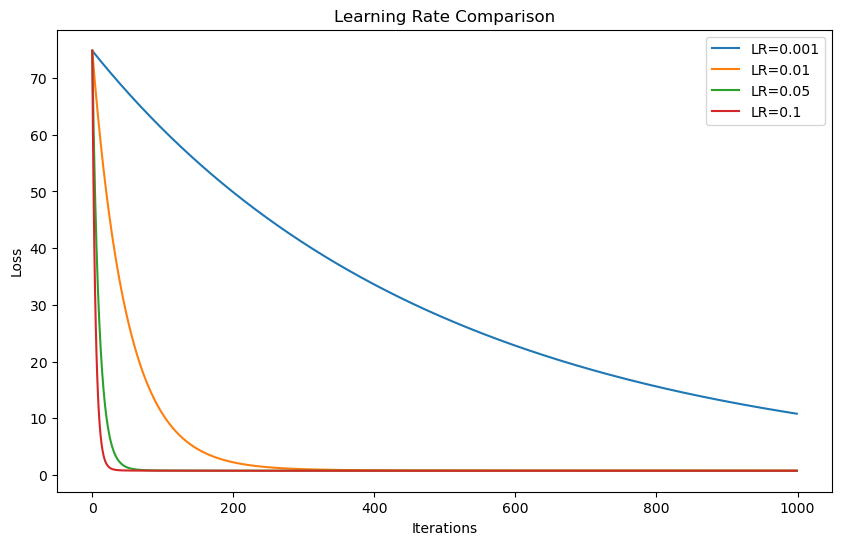

In [19]:
#task 6 
learning_rates = [0.001, 0.01, 0.05, 0.1]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for lr in learning_rates:

    model = LinearRegressionGD(
        learning_rate=lr,
        iterations=1000
    )

    model.fit(X_train, y_train)

    plt.plot(model.loss_history, label=f"LR={lr}")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

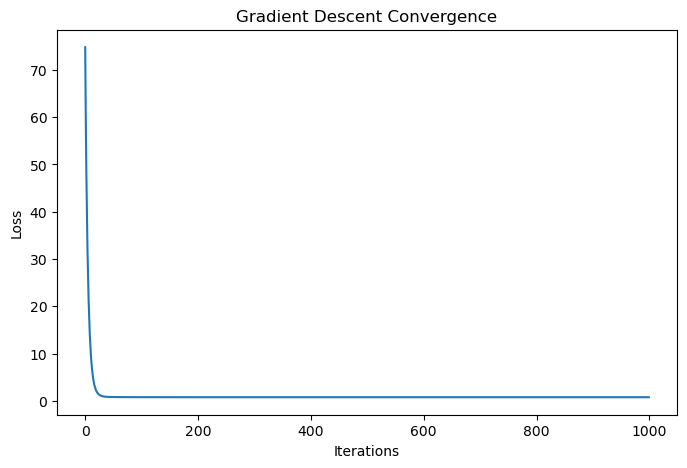

In [21]:
#task 7
plt.figure(figsize=(8,5))

plt.plot(model.loss_history)

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("Gradient Descent Convergence")

plt.show() 

In [23]:
#task 8 
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

MAE = mean_absolute_error(y_test, predictions)

MSE = mean_squared_error(y_test, predictions)

RMSE = np.sqrt(MSE)

R2 = r2_score(y_test, predictions)

print("Mean Absolute Error :", MAE)

print("Mean Squared Error :", MSE)

print("Root Mean Squared Error :", RMSE)

print("R2 Score :", R2)

Mean Absolute Error : 0.7696272532285766
Mean Squared Error : 1.4837079687939325
Root Mean Squared Error : 1.2180755185102163
R2 Score : 0.8478516014622373


In [25]:
#task 8
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

print(comparison.head(20))

    Actual  Predicted
0       19  18.152447
1       12  11.696944
2       18  18.340382
3       11  10.931049
4       11  11.903882
5       17  16.286762
6       18  17.416945
7        8   9.068148
8       10  11.017697
9       11  10.621588
10      18  18.401192
11      11  12.208921
12      12  12.424207
13       9   9.512790
14      12  11.493554
15      14  13.569828
16      13  11.735110
17       8   7.737720
18      15  15.664611
19      14  14.883131


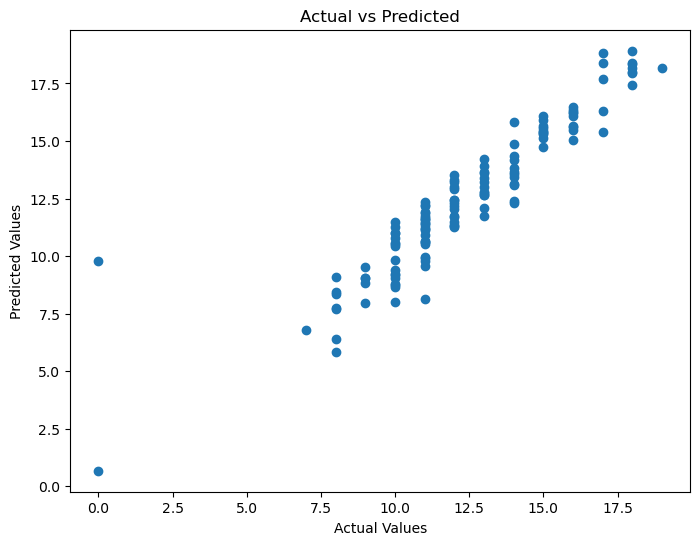

In [27]:
#task 9
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

Interpretation (Write in Your Lab Report)
Convergence Behavior
The loss decreases continuously with iterations.
A learning rate of 0.01 usually provides smooth convergence.
A very small learning rate (0.001) converges slowly.
A larger learning rate (0.1) converges faster but may oscillate or overshoot if too high.
Model Performance
MAE indicates the average absolute prediction error.
MSE penalizes larger prediction errors more heavily.
RMSE expresses the prediction error in the same units as the target variable.
R² Score shows how well the model explains the variance in the target values (closer to 1 indicates better performance).